# Backtest Long-Short sur le S&P 500

**Projet M2 IEF — Sacha Guerin & Hugo Rocha**

On construit et compare deux portefeuilles long-short market-neutral sur les constituants du S&P 500, de 2001 à 2025. Toutes les données viennent de Bloomberg (prix ajustés, P/E, composition historique point-in-time, T-Bill 3M).

Les deux stratégies sont rebalancées mensuellement et beta-neutralisées par rapport à un proxy equal-weight du S&P 500.

| | **PCA Stat-Arb** | **Value EW Beta-Neutral** |
|---|---|---|
| **Signal** | Mean-reversion des résidus d'une ACP sur les rendements | Tri par P/E ratio (cheap vs expensive) |
| **Allocation** | Vol-targeting + filtre de régime | Equal-weight + low-vol tilt |
| **Neutralisation** | Dollar-neutral + beta-neutral | Beta-neutral |


## I. Imports et configuration

In [18]:
import sys, time, importlib
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# chemins projet
PROJECT_DIR = Path(".").resolve()
sys.path.insert(0, str(PROJECT_DIR / "src"))
sys.path.insert(0, str(PROJECT_DIR / "src" / "backtest"))

# reload si on modifie les modules
import backtest.visualisation as _vis_mod
importlib.reload(_vis_mod)

from backtest.pca_statarb import PCAStatArbStrategy, compute_rolling_beta, subperiod_metrics
from backtest.signals import ValueSignalGenerator, get_rebalance_dates
from backtest.allocation import AllocationEngine
from backtest.indicators import calculate_all_metrics, format_metrics_table
from backtest.visualisation import (
    plot_equity_curve, plot_risk_dashboard, plot_multi_equity,
    plot_multi_risk_dashboard, plot_metrics_comparison, print_beta_diagnostics,
)

# config backtest
START = "2001-01-01"
END   = "2025-12-31"
DATA_DIR = PROJECT_DIR / "data" / "raw"
OUT_DIR  = PROJECT_DIR / "outputs"
OUT_DIR.mkdir(exist_ok=True)

## II. Données

On charge les données depuis des fichiers parquet locaux (ou directement depuis Bloomberg si c'est la première exécution).

- **prices** : prix ajustés quotidiens de tous les constituants historiques du S&P 500
- **pe_ratios** : P/E trailing pour le signal value
- **universe** : composition du S&P 500 à chaque date (point-in-time, pour éviter le survivorship bias)
- **risk_free** : T-Bill 3M en taux annuel


In [19]:
from backtest.bloomberg import fetch_or_load, data_exists, EXPECTED_FILES

INDEX_NAME     = "SPX"            # SPX, MID, SML, RTY, RIY
FORCE_REFRESH  = False            # True = re-telecharge meme si fichiers presents

if not data_exists(str(DATA_DIR)):
    ans = input("Telecharger donnees depuis Bloomberg ? [O/n] : ").strip().lower()
    if ans not in ("", "o", "oui", "y", "yes"):
        raise SystemExit("Donnees manquantes, arret.")
    FORCE_REFRESH = True

# chargement ou telechargement
data = fetch_or_load(
    index_name=INDEX_NAME,
    start_date=START,
    end_date=END,
    output_path=str(DATA_DIR),
    force_refresh=FORCE_REFRESH,
)

prices    = data["prices"]
pe_ratios = data["pe_ratios"]
universe  = data["universe"]
risk_free = data["risk_free"]

# mise en forme des index
prices.index = pd.to_datetime(prices.index)
prices = prices.sort_index().loc[:END]

pe_ratios.index = pd.to_datetime(pe_ratios.index)
pe_ratios = pe_ratios.sort_index().loc[:END]

universe["date"] = pd.to_datetime(universe["date"])

risk_free.index = pd.to_datetime(risk_free.index)
risk_free = risk_free.sort_index().loc[START:END]

Données déjà présentes dans C:\Users\Sebastian\Desktop\PERSO\BLOOMBERG_API-main\equity-basket\data\raw/ -- chargement depuis le disque.


In [20]:
# Proxy S&P 500 equal-weight
daily_rets = prices.pct_change(fill_method=None)
universe_grp = universe.groupby("date")["ticker"].apply(set).to_dict()
univ_dates_sorted = sorted(universe_grp.keys())

spx_ew_rows = []
for date in daily_rets.index:
    if date < pd.Timestamp(START) or date > pd.Timestamp(END):
        continue
    candidates = [d for d in univ_dates_sorted if d <= date]
    if not candidates:
        continue
    members = universe_grp[candidates[-1]]
    available = [t for t in members if t in daily_rets.columns]
    if len(available) < 10:
        continue
    r = daily_rets.loc[date, available].dropna()
    if len(r) > 0:
        spx_ew_rows.append({"date": date, "ret": r.mean()})

spx_ew_ret = pd.DataFrame(spx_ew_rows).set_index("date")["ret"]
spx_ew = (1 + spx_ew_ret).cumprod()

# Risk-free level
rf_daily_rate = risk_free / 100 / 252
rf_level = (1 + rf_daily_rate).cumprod()
rf_level.name = "Rf_level"

## III. Paramètres

Les hyperparamètres des deux stratégies ont été optimisés par grid search (~10h au total). Le critère principal est le Sharpe ratio, avec une contrainte sur le beta moyen absolu (<0.15).

Les résultats sont stockés dans `outputs/gs_pca_best.json` et `gs_value_best.json`. On les charge directement ici, sauf si on souhaite relancer l'optimisation.


In [21]:
import subprocess, sys
from backtest.utils import load_best_params, run_gridsearch

# parametres par defaut (fallback si une cle manque dans le JSON)
BEST_PCA = dict(
    n_components=8, lookback=504, min_history=252,
    zscore_window=60, entry_zscore=1.0,
    max_holding_days=120, min_holding_days=21,
    max_positions_per_side=50,
    vol_target=0.15, max_gross=4.0, tc_bps=5,
    half_life_min=1, half_life_max=30, max_resid_vol_mult=4.0,
    regime_vol_window=63, regime_vol_cap=2.0,
    beta_lookback=252, rebalance_freq="ME",
)
BEST_VALUE = dict(
    n_buckets=7, long_buckets=[1], short_buckets=[7],
    vol_window=90, beta_lookback=504, tc_bps=5,
    use_low_vol=True,
)

pca_gs_path = OUT_DIR / "gs_pca_best.json"
val_gs_path = OUT_DIR / "gs_value_best.json"

print(
    "INFO : Les gridsearch ont déjà été exécutés et leurs résultats sont\n"
    "       sauvegardés dans outputs/ (gs_pca_best.json, gs_value_best.json).\n"
    "       Les relancer intégralement prend environ 10 heures.\n"
    "       Répondre 'Non' charge directement les paramètres existants."
)
choice = input("Relancer les gridsearch (voir print) ? [Oui/Non] : ").strip().lower()

if choice in ("o", "oui", "y", "yes"):
    GS_DIR = PROJECT_DIR / "src" / "backtest"
    run_gridsearch("gridsearch_value.py", PROJECT_DIR, GS_DIR)
    run_gridsearch("gridsearch_pca.py", PROJECT_DIR, GS_DIR)

# chargement des params depuis les JSON
if not pca_gs_path.exists() or not val_gs_path.exists():
    missing = [p.name for p in (pca_gs_path, val_gs_path) if not p.exists()]
    raise FileNotFoundError(
        f"Fichier(s) manquant(s) dans outputs/ : {', '.join(missing)}\n"
        "Relancez les gridsearch ou placez les JSON dans outputs/."
    )

pca_params = load_best_params(pca_gs_path, BEST_PCA)
print("PCA Stat-Arb :")
for k, v in pca_params.items():
    print(f"  {k} = {v}")

value_params = load_best_params(val_gs_path, BEST_VALUE)
print("\nValue EW bN :")
for k, v in value_params.items():
    print(f"  {k} = {v}")


INFO : Les gridsearch ont déjà été exécutés et leurs résultats sont
       sauvegardés dans outputs/ (gs_pca_best.json, gs_value_best.json).
       Les relancer intégralement prend environ 10 heures.
       Répondre 'Non' charge directement les paramètres existants.
PCA Stat-Arb :
  n_components = 8
  lookback = 504
  min_history = 252
  zscore_window = 60
  entry_zscore = 1.0
  max_holding_days = 120
  min_holding_days = 21
  max_positions_per_side = 50
  vol_target = 0.15
  max_gross = 4.0
  tc_bps = 5
  half_life_min = 1
  half_life_max = 30
  max_resid_vol_mult = 4.0
  regime_vol_window = 63
  regime_vol_cap = 2.0
  beta_lookback = 252
  rebalance_freq = ME

Value EW bN :
  n_buckets = 7
  long_buckets = [1]
  short_buckets = [7]
  vol_window = 40
  beta_lookback = 504
  tc_bps = 5
  use_low_vol = True


## IV. PCA Stat-Arb

On applique une ACP glissante sur les rendements des constituants du S&P 500. Pour chaque titre, on isole le résidu (la partie idiosyncratique une fois les facteurs communs retirés), puis on calcule un z-score glissant sur ce résidu cumulé.

- **Long** quand le z-score est très négatif (le titre a sous-performé vs les facteurs → pari sur un retour à la moyenne)
- **Short** quand il est très positif

Le portefeuille est rendu beta-neutral à chaque rebalancement.


In [22]:
pca_strat = PCAStatArbStrategy(**pca_params)
pca_results = pca_strat.run(
    prices=prices, universe=universe, benchmark=spx_ew,
    start_date=START, end_date=END, risk_free=risk_free,
)
pca_track = pca_results["track"]
pca_weights = pca_results.get("weights", pd.DataFrame())

PCA Stat-Arb


### Métriques

In [23]:
rf_mean = risk_free.mean() / 100 if risk_free.mean() > 1 else risk_free.mean()

# benchmark = proxy EW S&P 500 (pas le risk-free)
bm_ret_pca = spx_ew_ret.reindex(pca_track["date"].values).fillna(0)

pca_metrics = calculate_all_metrics(
    pca_track, risk_free_rate=rf_mean, benchmark_returns=bm_ret_pca,
)
print(format_metrics_table(pca_metrics).to_string())

# sous-periodes
print("\n" + subperiod_metrics(pca_track, risk_free_rate=rf_mean).to_string(index=False))

      Category                Metric       Value
0    Rendement          Total Return     180.08%
1    Rendement                  CAGR       4.21%
2    Rendement     Total Value (NAV)  $2,800,793
3    Rendement     Daily Mean Return     1.74 bp
4       Risque        Annualised Vol       7.20%
5       Risque          Max Drawdown     -28.78%
6   VaR / CVaR       VaR 95 % (hist)       0.67%
7   VaR / CVaR       VaR 99 % (hist)       1.11%
8   VaR / CVaR             CVaR 95 %       0.95%
9   VaR / CVaR             CVaR 99 %       1.44%
10      Ratios          Sharpe Ratio       0.365
11      Ratios         Sortino Ratio       0.571
12      Ratios          Calmar Ratio       0.146
13      Ratios    Alpha vs Rf (ann.)       2.46%
14     Trading              Win Rate      50.69%
15     Trading         Profit Factor        1.11
16     Trading         Avg Positions          96
17     Trading    Avg Gross Exposure        2.13
18     Trading      Avg Net Exposure     -0.0108
19     Trading      

### Graphiques

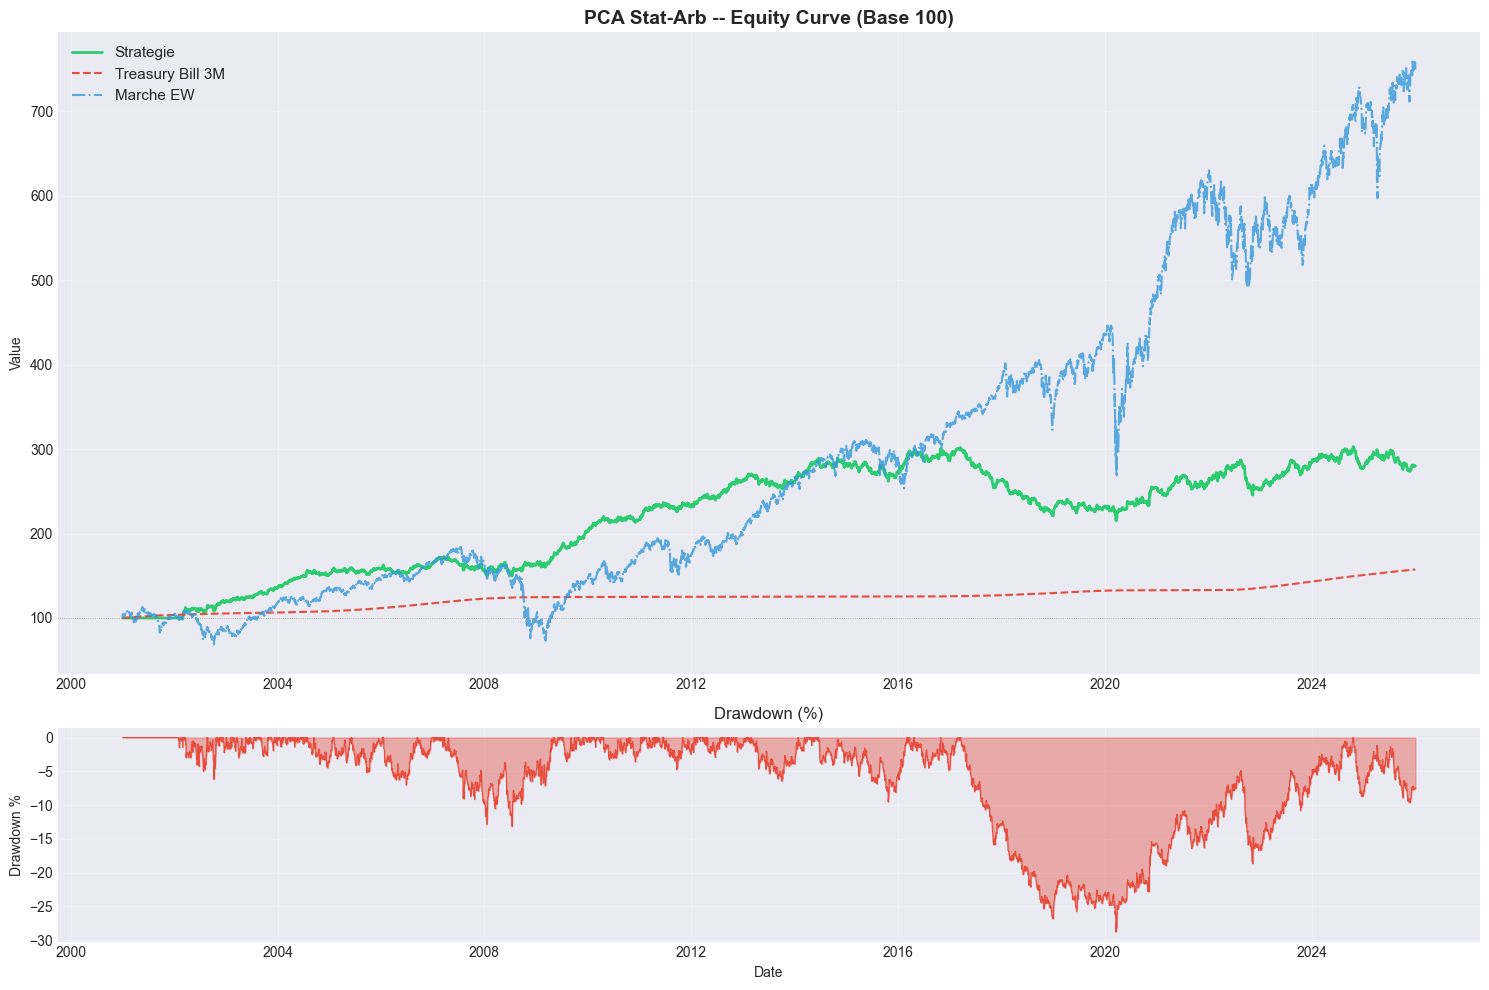

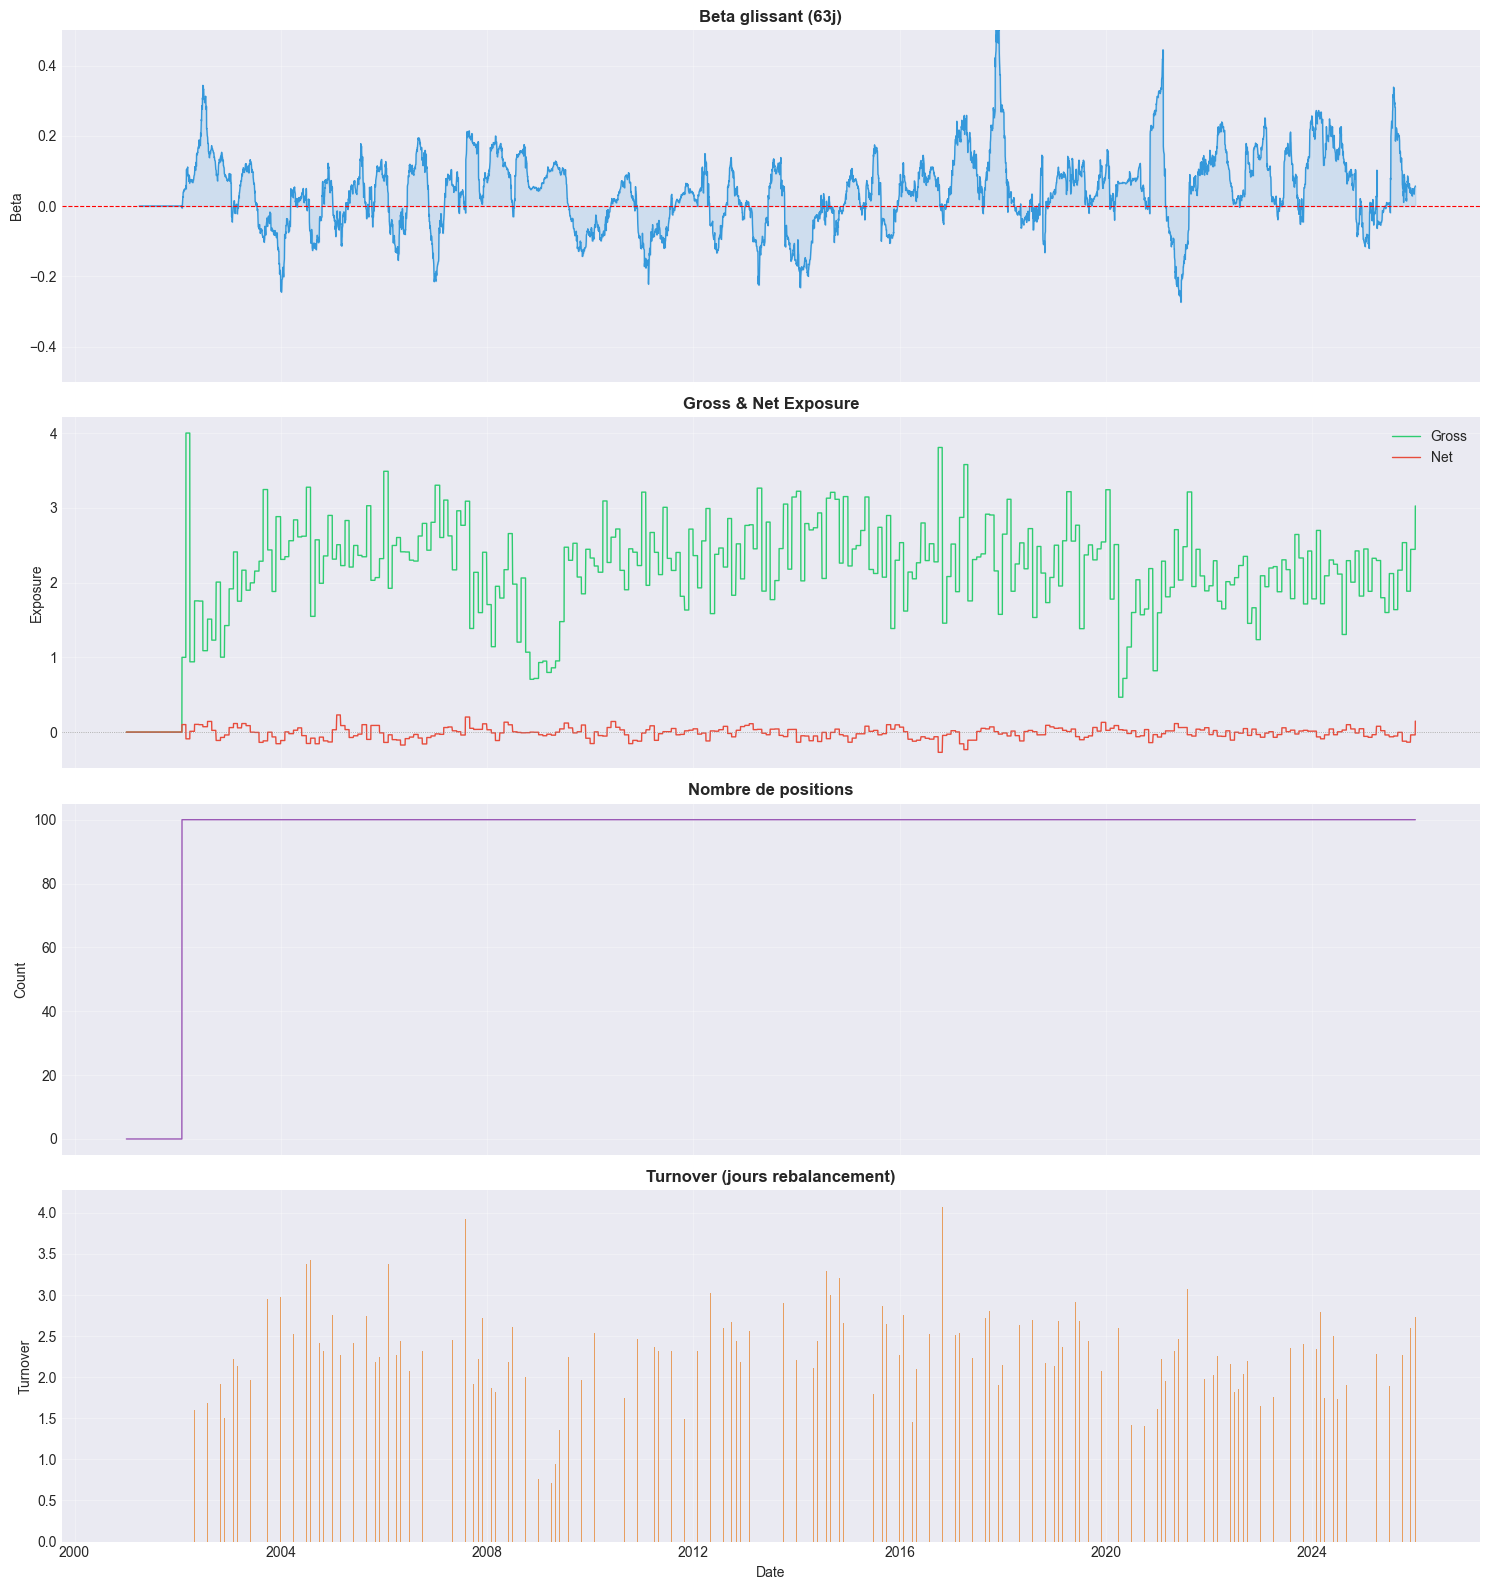

Beta glissant (6225 jours):
  Moy: 0.0408
  Med: 0.0393
  Std: 0.1036
  Min: -0.2740
  Max: 0.5316


In [24]:
plot_equity_curve(pca_track, rf_level, spx_ew, title="PCA Stat-Arb -- Equity Curve (Base 100)")

rb_pca = compute_rolling_beta(pca_track, spx_ew, window=63)
plot_risk_dashboard(pca_track, rb_pca)
print_beta_diagnostics(rb_pca)

## V. Value EW Beta-Neutral

Approche classique : on trie les titres par P/E ratio et on achète les moins chers (bucket 1) en shortant les plus chers (bucket 7).

Les poids sont equal-weight dans chaque jambe, avec un tilt optionnel vers les titres à faible volatilité réalisée. On neutralise ensuite le beta vs le proxy S&P EW, et on applique des coûts de transaction de 5 bps par trade.


In [25]:
from backtest.allocation import beta_neutralize_weights
from backtest.engine import run_multifactor_backtest

# signaux value
rebal_dates = get_rebalance_dates(pd.Timestamp(START), pd.Timestamp(END), "ME")

sig_gen = ValueSignalGenerator(
    n_buckets=value_params["n_buckets"],
    long_buckets=value_params["long_buckets"],
    short_buckets=value_params["short_buckets"],
    buffer=value_params.get("buffer", 0),
)
signals = sig_gen.generate_signals(
    prices=prices, pe_ratios=pe_ratios, rebalance_dates=rebal_dates,
    universe=universe, use_low_vol=value_params["use_low_vol"],
    vol_window=value_params["vol_window"],
)

# allocation equal-weight
engine = AllocationEngine(
    method="equal_weight", vol_window=value_params["vol_window"],
    long_target=1.0, short_target=-1.0,
)
weights_raw = engine.generate_weights(
    signals=signals, prices=prices,
    rebalance_dates=rebal_dates, signal_type="value",
)

# neutralisation beta (vs proxy EW)
weights = beta_neutralize_weights(
    weights_raw, prices, spx_ew, lookback=value_params["beta_lookback"],
)

# backtest
value_track = run_multifactor_backtest(
    prices, weights, start_date=START, end_date=END,
    initial_capital=1_000_000, tc_bps=value_params["tc_bps"],
)

C:\Users\Sebastian\Desktop\PERSO\BLOOMBERG_API-main\equity-basket\src\backtest\signals.py:315: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = out.groupby("date", group_keys=False).apply(_per_date)
C:\Users\Sebastian\Desktop\PERSO\BLOOMBERG_API-main\equity-basket\src\backtest\signals.py:315: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out = out.groupby("date", group_keys=False).apply(_per_date)


### Métriques

In [26]:
bm_ret_val = spx_ew_ret.reindex(value_track["date"].values).fillna(0)

value_metrics = calculate_all_metrics(
    value_track, risk_free_rate=rf_mean, benchmark_returns=bm_ret_val,
)
print(format_metrics_table(value_metrics).to_string())

      Category                Metric       Value
0    Rendement          Total Return     121.14%
1    Rendement                  CAGR       3.23%
2    Rendement     Total Value (NAV)  $2,211,390
3    Rendement     Daily Mean Return     1.39 bp
4       Risque        Annualised Vol       8.00%
5       Risque          Max Drawdown     -24.99%
6   VaR / CVaR       VaR 95 % (hist)       0.68%
7   VaR / CVaR       VaR 99 % (hist)       1.35%
8   VaR / CVaR             CVaR 95 %       1.11%
9   VaR / CVaR             CVaR 99 %       1.97%
10      Ratios          Sharpe Ratio       0.218
11      Ratios         Sortino Ratio       0.310
12      Ratios          Calmar Ratio       0.129
13      Ratios    Alpha vs Rf (ann.)       1.48%
14     Trading              Win Rate      50.49%
15     Trading         Profit Factor        1.09
16     Trading         Avg Positions         133
17     Trading    Avg Gross Exposure        1.04
18     Trading      Avg Net Exposure      0.0129
19     Trading      

### Graphiques

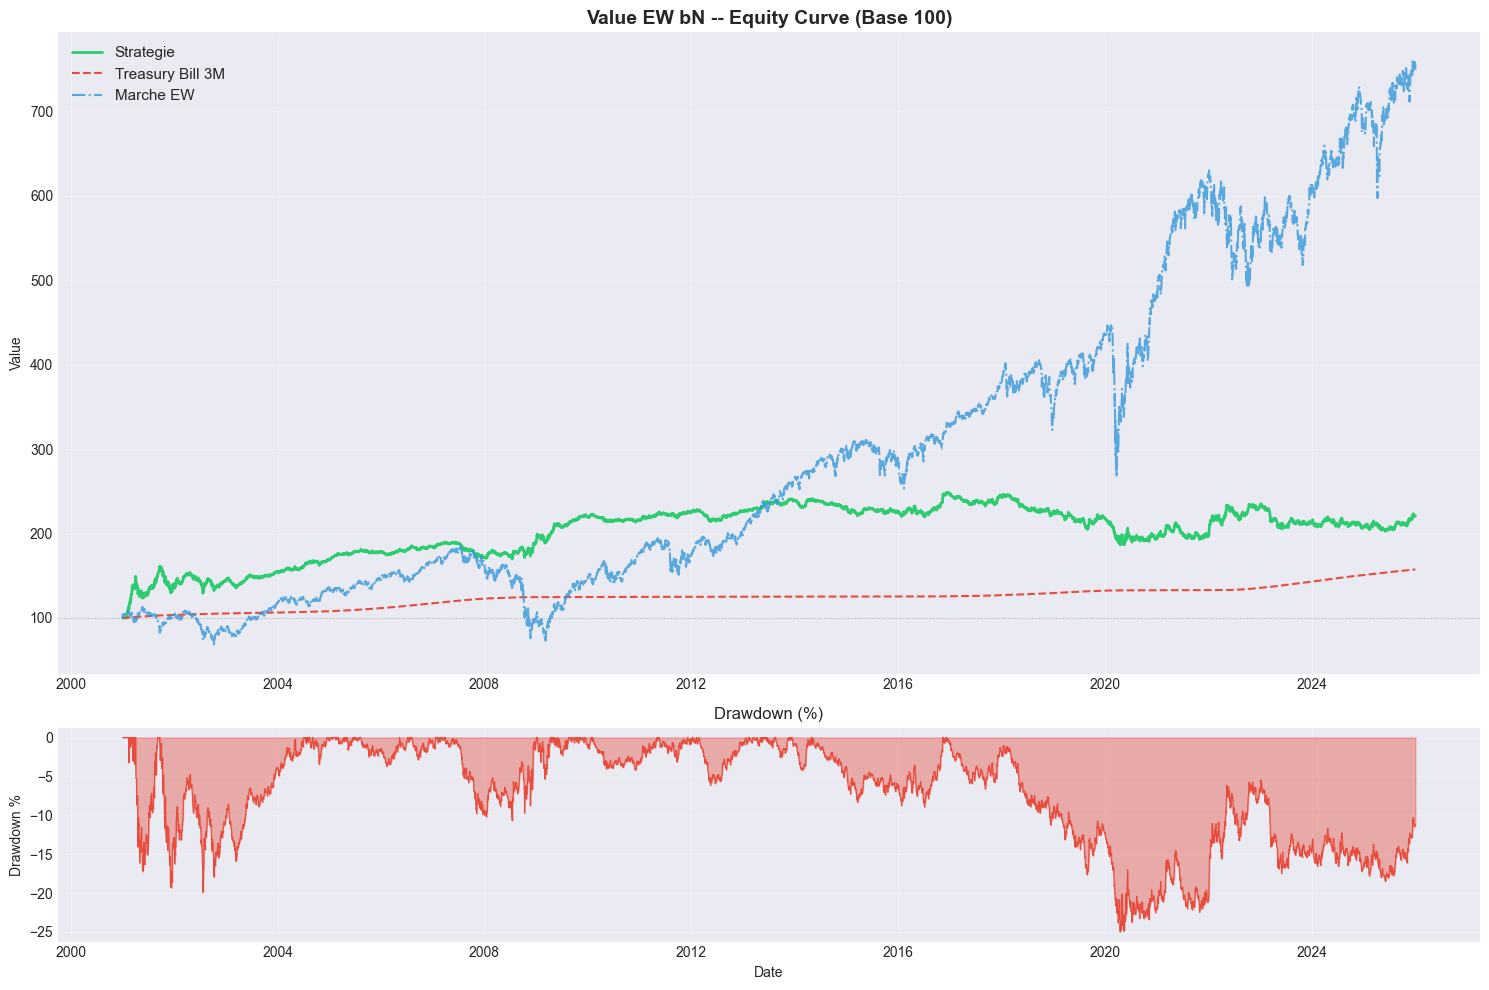

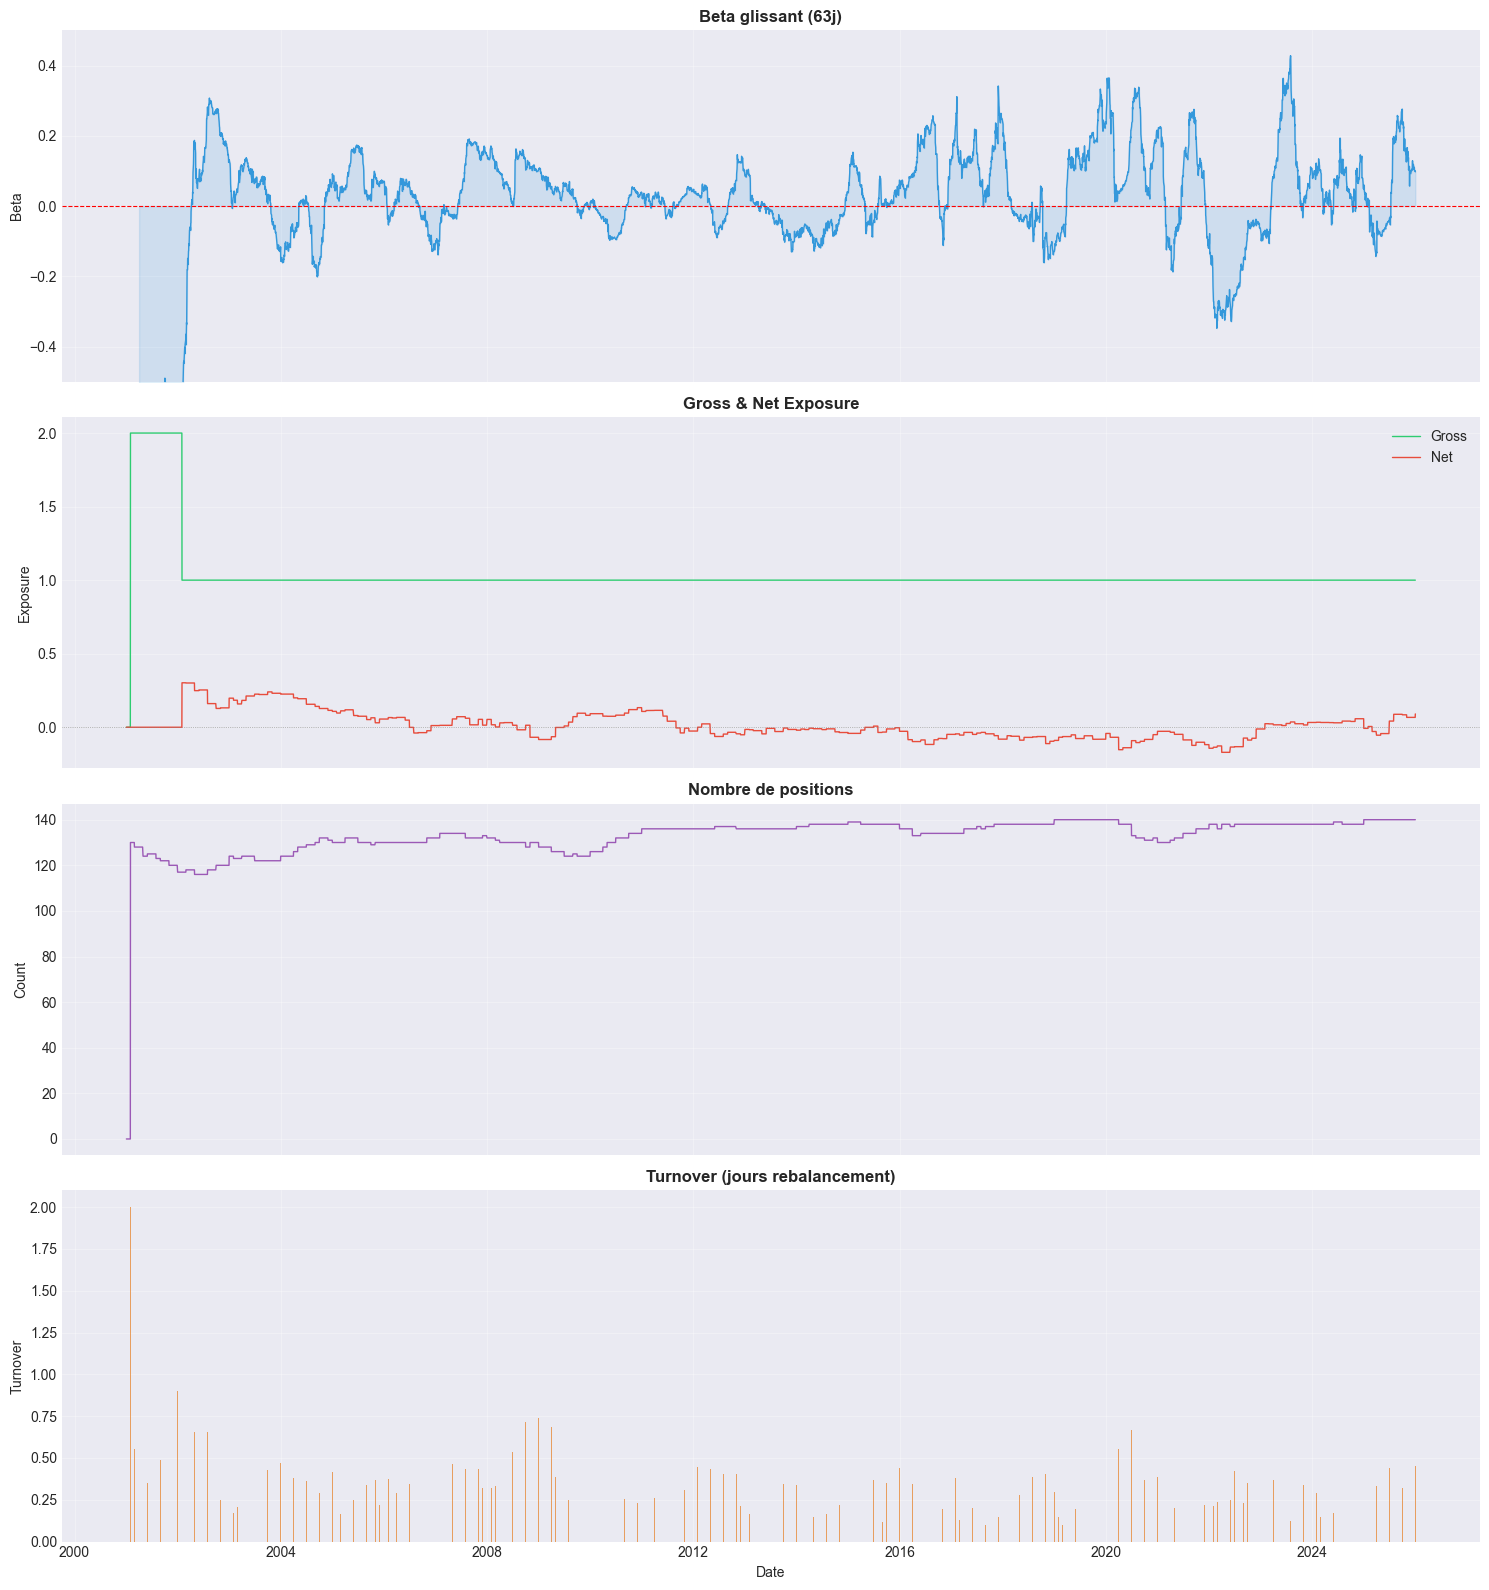

Beta glissant (6225 jours):
  Moy: 0.0133
  Med: 0.0308
  Std: 0.1754
  Min: -0.9461
  Max: 0.4280


In [27]:
plot_equity_curve(value_track, rf_level, spx_ew, title="Value EW bN -- Equity Curve (Base 100)")

rb_value = compute_rolling_beta(value_track, spx_ew, window=63)
plot_risk_dashboard(value_track, rb_value)
print_beta_diagnostics(rb_value)

## VI. Comparaison

Overlay des equity curves et des risk dashboards des deux stratégies pour comparer visuellement leurs profils de rendement et de risque.


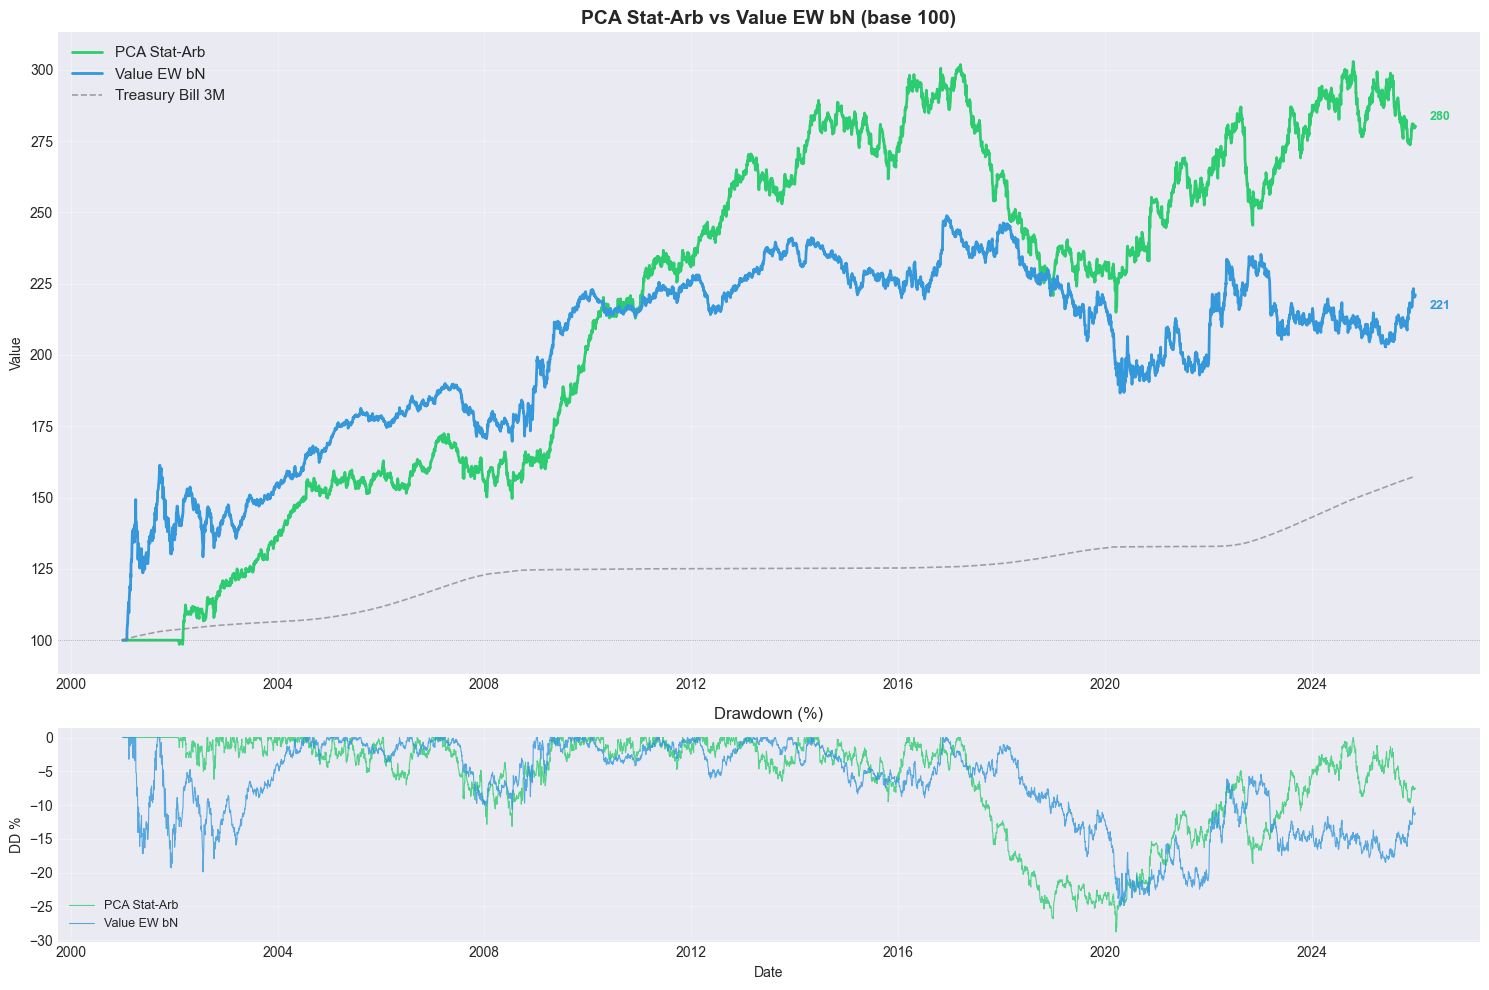

In [28]:
tracks = {"PCA Stat-Arb": pca_track, "Value EW bN": value_track}
plot_multi_equity(tracks, benchmark=rf_level, title="PCA Stat-Arb vs Value EW bN (base 100)")

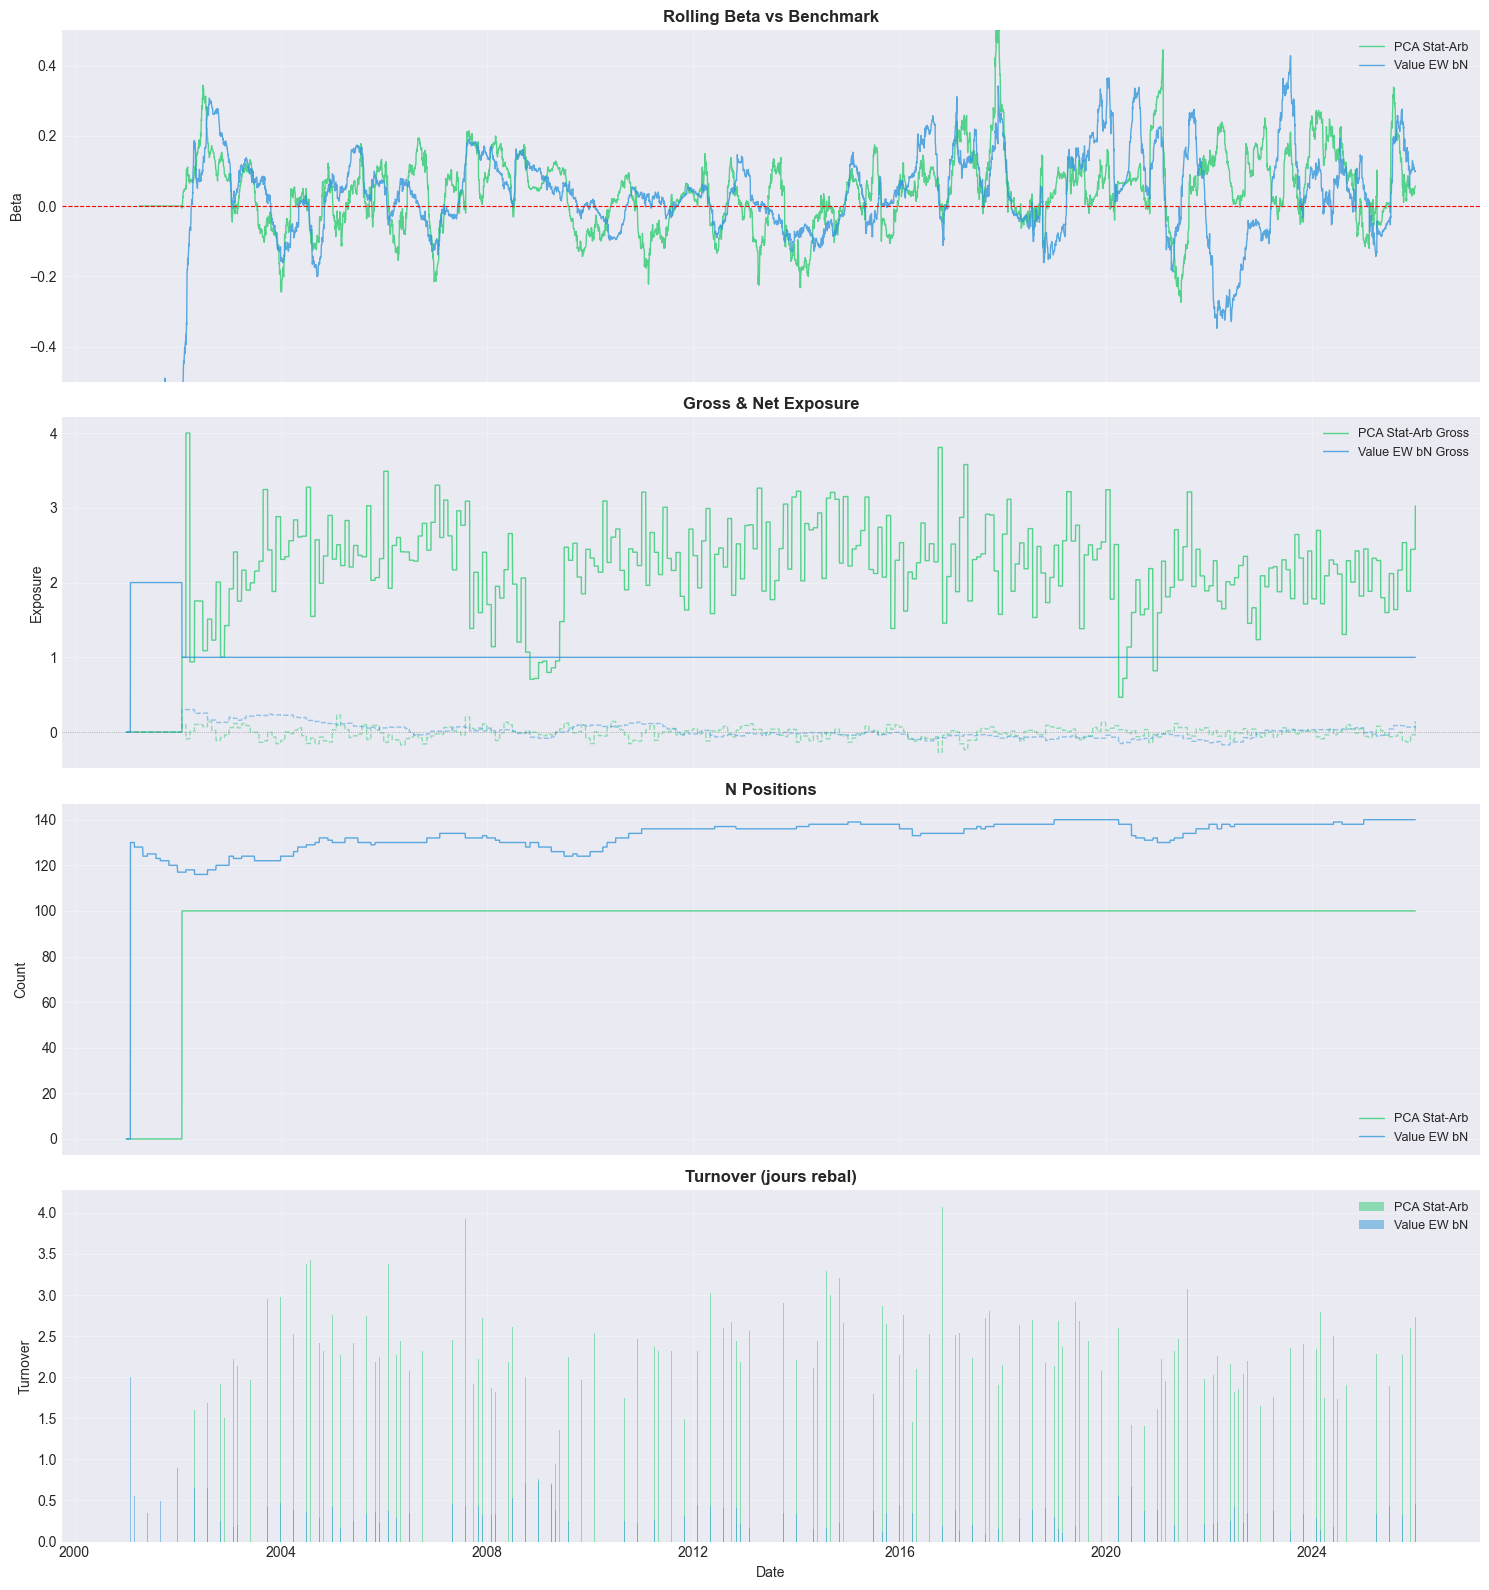

In [29]:
rolling_betas = {"PCA Stat-Arb": rb_pca, "Value EW bN": rb_value}
plot_multi_risk_dashboard(tracks, rolling_betas=rolling_betas)

## VII. Exports BBU

Pour chaque stratégie, on exporte un fichier XLSX compatible Bloomberg PORT, uploadable directement via BBU.

On exporte aussi le benchmark (risk-free) en CSV pour l'importer sur Bloomberg


In [30]:
from backtest.port import export_portfolio_xlsx

REPORTS_DIR = OUT_DIR / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# export PCA Stat-Arb
pca_weights = pca_results.get("weights", pd.DataFrame())
if not pca_weights.empty:
    pca_xlsx = export_portfolio_xlsx(
        pca_weights,
        strategy_name="PCA_STAT_ARB",
        track=pca_track,
        metrics=pca_metrics,
        output_path=REPORTS_DIR,
    )

# export Value EW bN
value_xlsx = export_portfolio_xlsx(
    weights,
    strategy_name="VALUE_EW_BN",
    track=value_track,
    metrics=value_metrics,
    output_path=REPORTS_DIR,
)

C:\Users\Sebastian\Desktop\PERSO\BLOOMBERG_API-main\equity-basket\src\backtest\port.py:52: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("date", group_keys=False).apply(_normalize_ls)
C:\Users\Sebastian\Desktop\PERSO\BLOOMBERG_API-main\equity-basket\src\backtest\port.py:85: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = raw_weights.groupby("date").apply(lambda x: pd.Series({
C:\Users\Sebastia

In [31]:
# export risk-free en CSV
rf_csv = REPORTS_DIR / "risk_free.csv"
rf_export = risk_free.copy()
rf_export.index.name = "Date"
rf_export.name = "rate_pct"
rf_export.to_csv(rf_csv)

In [32]:
# resume des fichiers generes
print(f"\nFichiers dans {REPORTS_DIR.name}/ :")
for f in sorted(REPORTS_DIR.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.0f} KB)")


Fichiers dans reports/ :
  portfolio_PCA_STAT_ARB.xlsx  (661 KB)
  portfolio_VALUE_EW_BN.xlsx  (894 KB)
  risk_free.csv  (120 KB)


## VIII. Results BBU

### VIII.A PCA Strategy

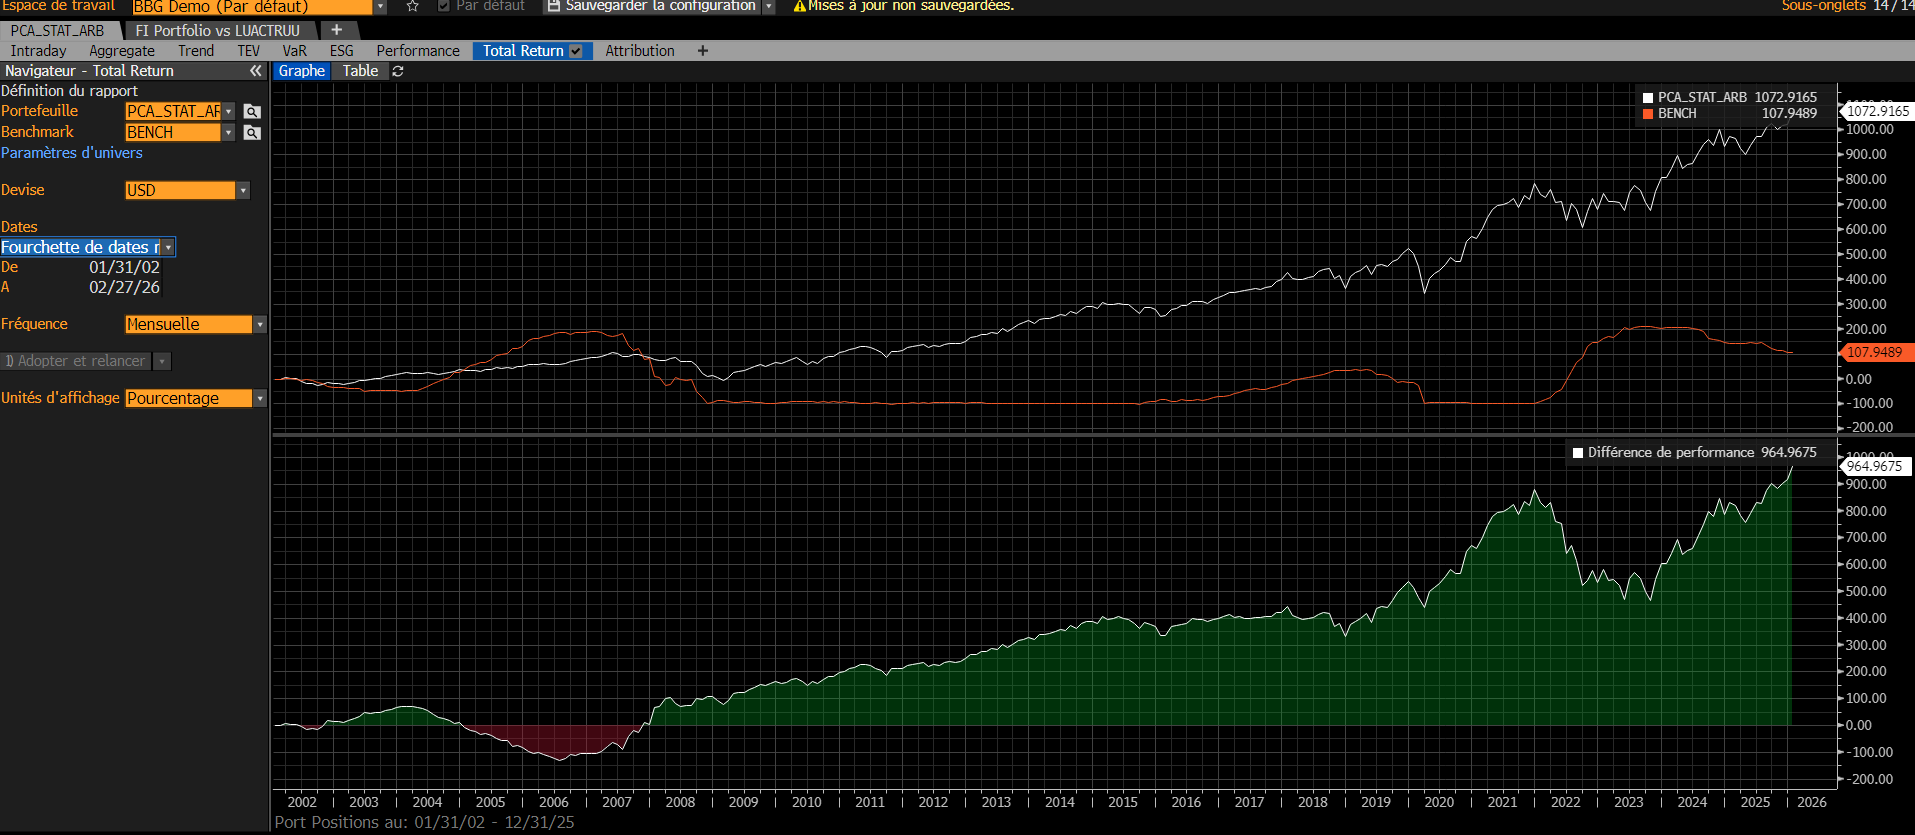

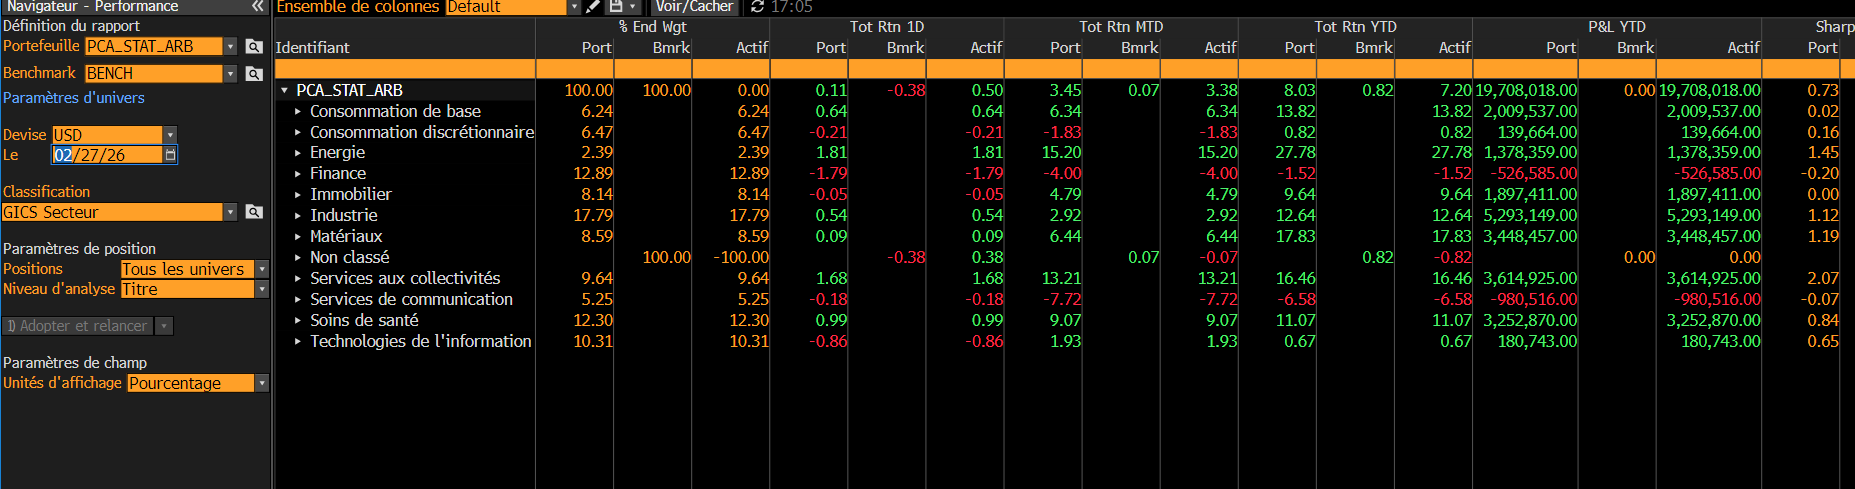

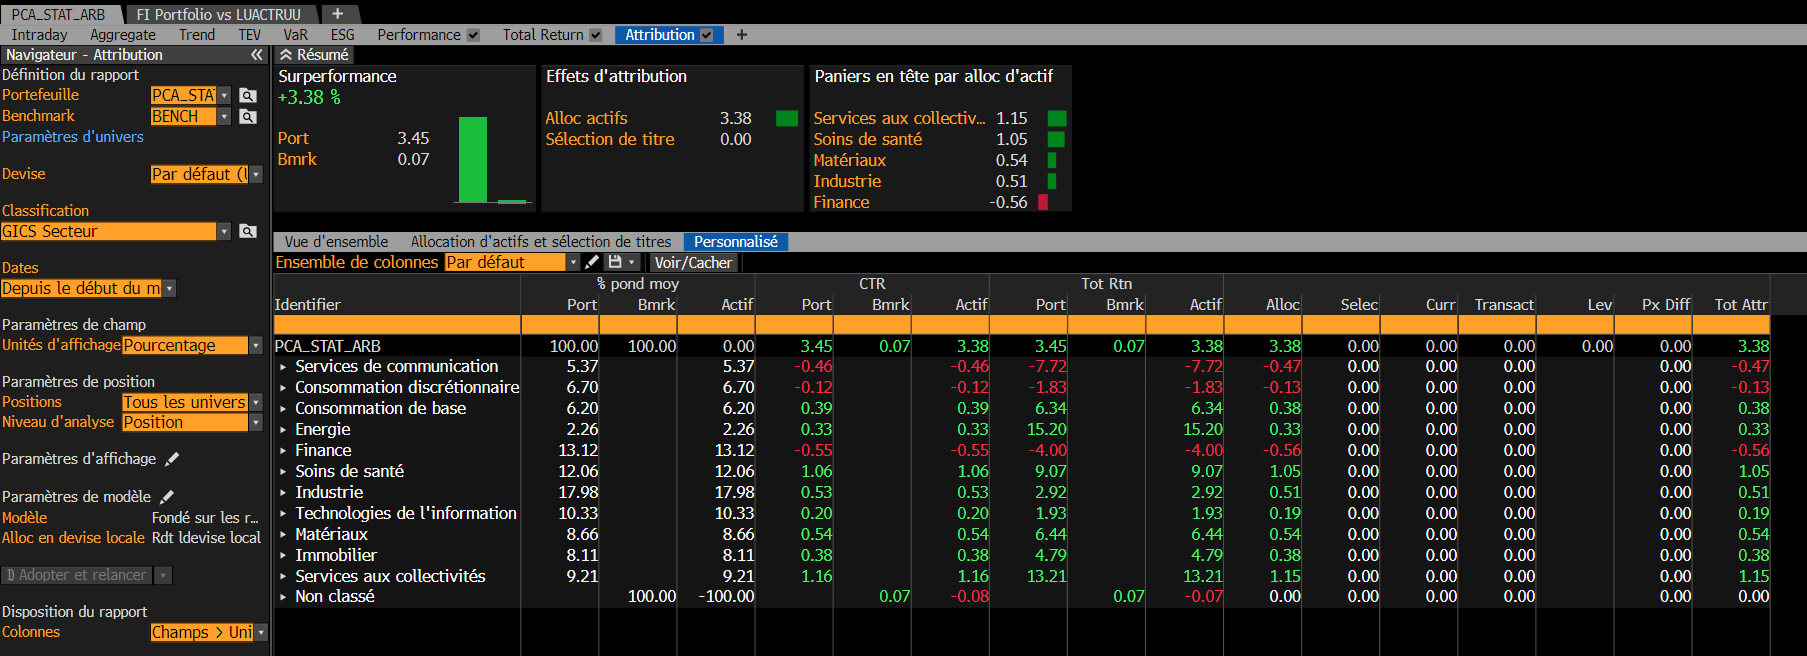

In [33]:
from IPython.display import display, Image

for i in (1, 2, 3):
    display(Image(filename=str(OUT_DIR / f"PCA_{i}.png")))


### VIII.B Value Strategy

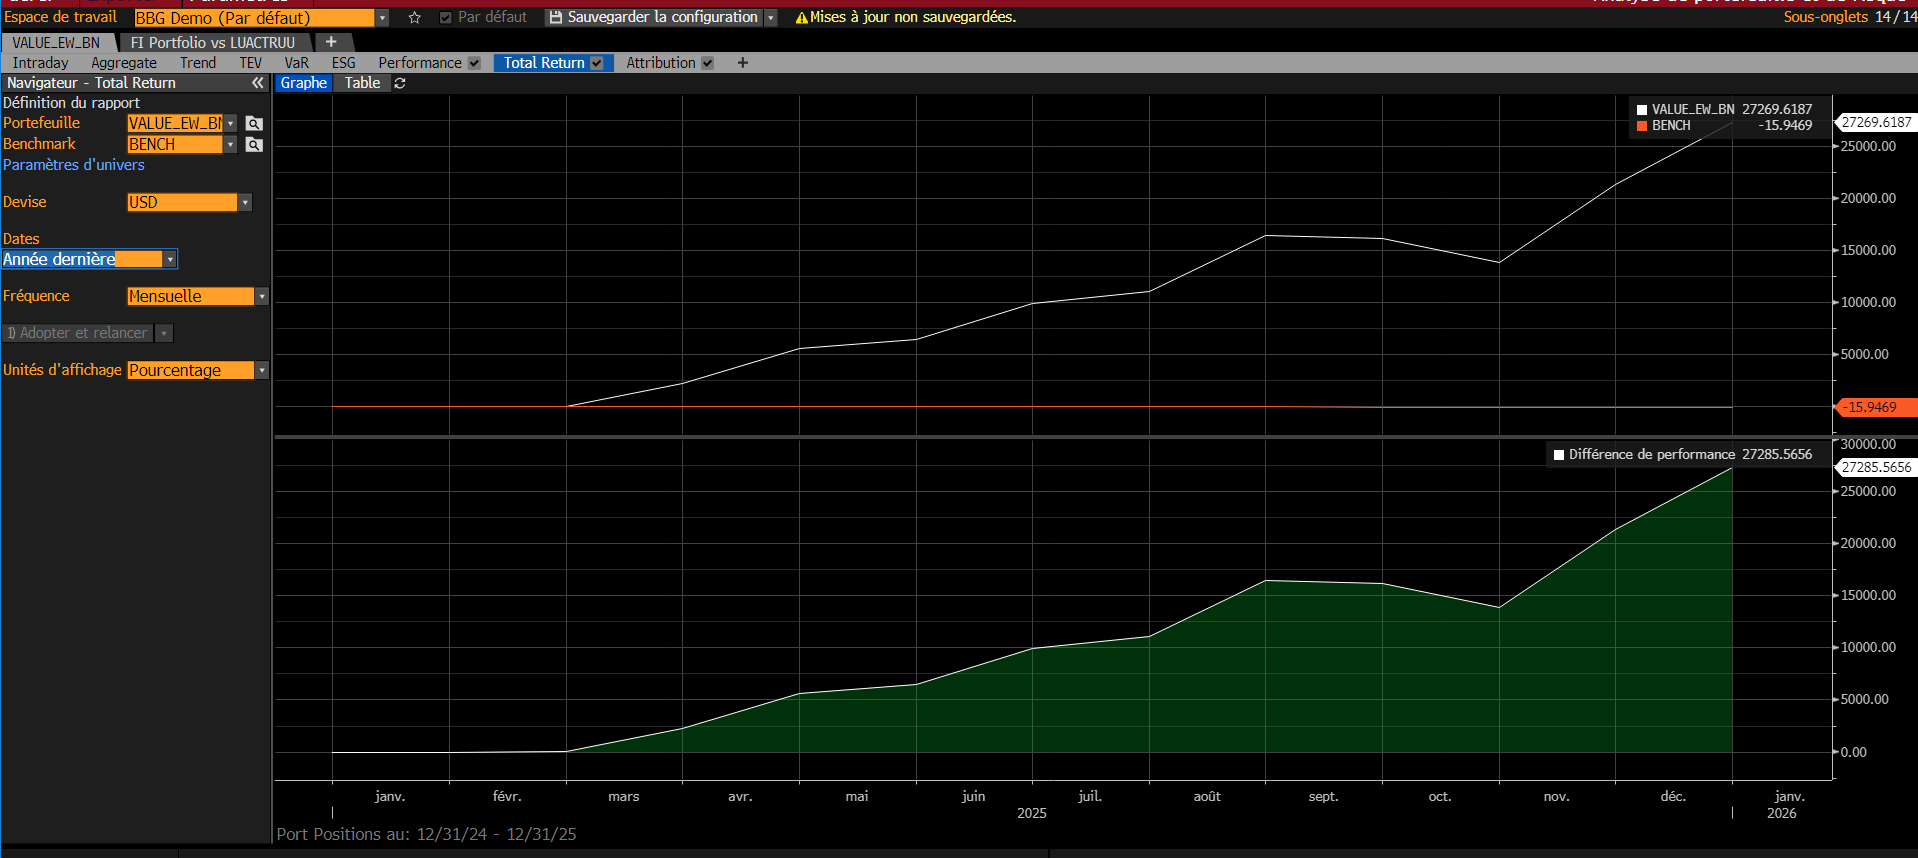

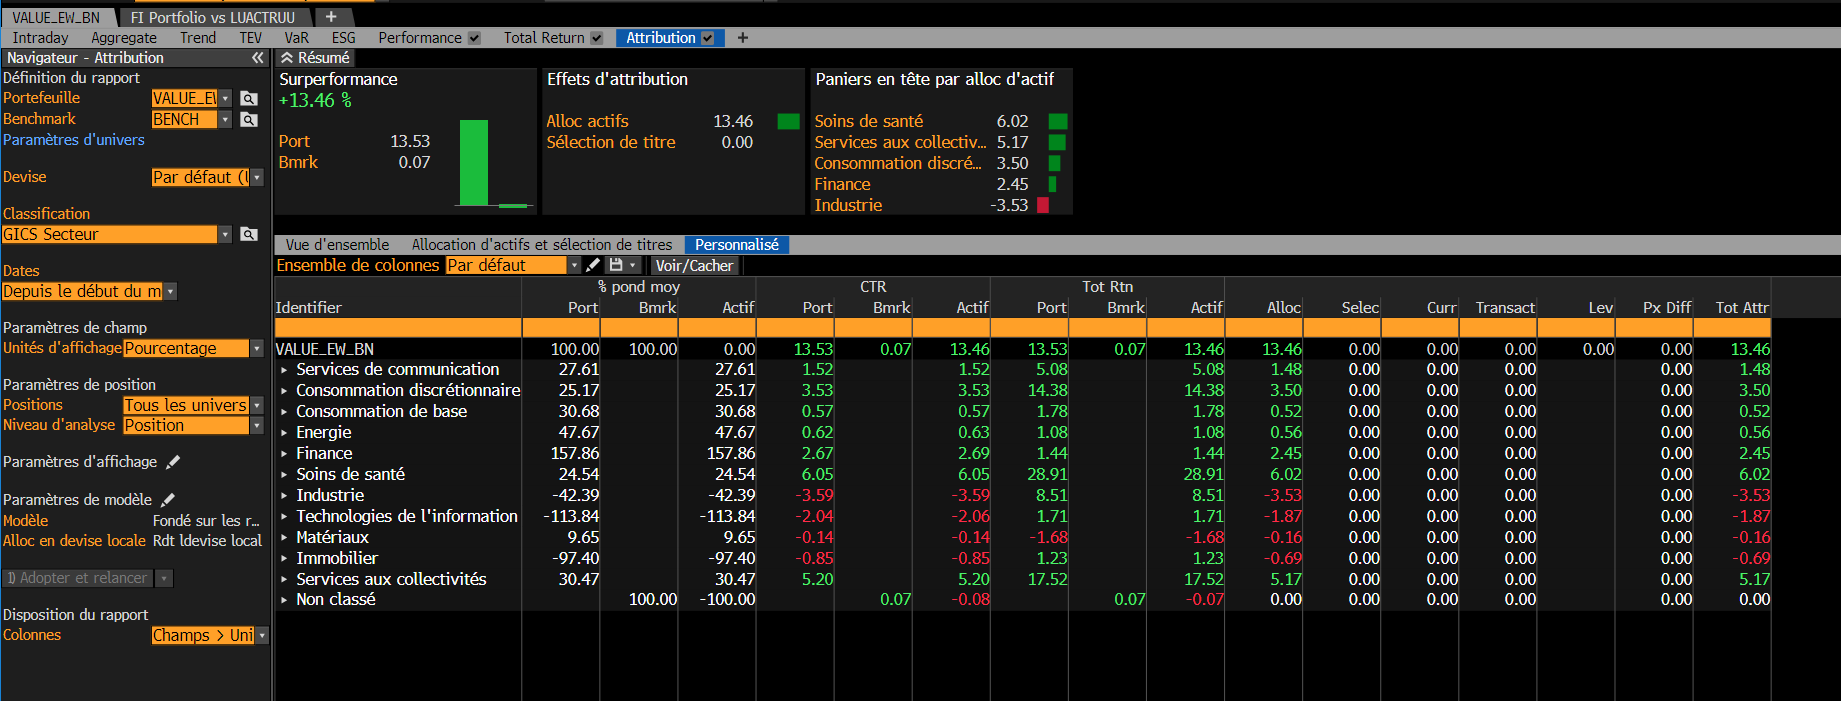

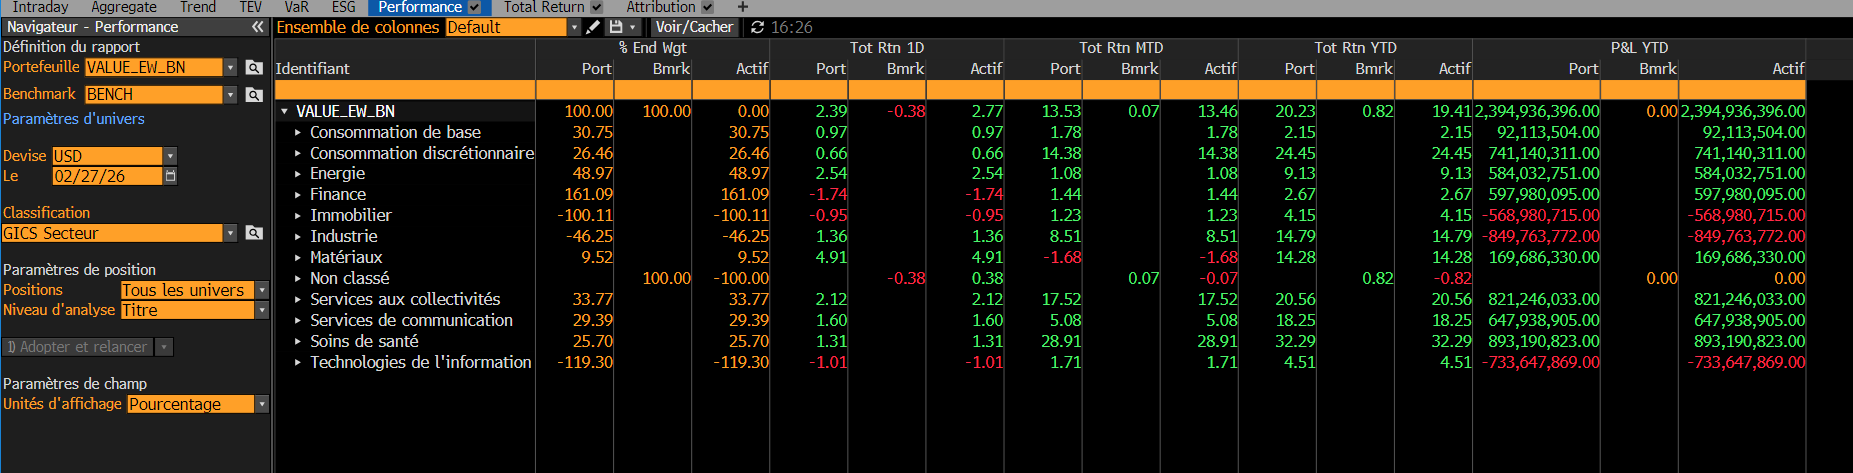

In [34]:
for i in (1, 2, 3):
    display(Image(filename=str(OUT_DIR / f"VALUE_{i}.png")))
